In [13]:
import numpy as np
import pandas as pd
import joblib

In [9]:
model_data = pd.read_parquet("../data/processed/preprocessed_data_enriched.parquet")

daily_inventory = pd.read_csv("../reports/daily_reorder_policy.csv")

model_data.head(20)


,id,item_id,d,sales,date,wm_yr_wk,wday,month,year,snap_CA,...,event_name_2_No_Event,event_name_2_OrthodoxEaster,event_type_2_Cultural,event_type_2_No_Event,event_type_2_Religious,weekday_sin,weekday_cos,days_since_last_sale,item_mean_sales,item_wday_mean
0,FOODS_1_001_CA_1_validation,0,d_29,2,2011-02-26,11105,1,2,2011,0,...,1,0,0,1,0,-0.974928,-0.222521,999,0.000000,0.0
1,FOODS_1_001_CA_1_validation,0,d_30,2,2011-02-27,11105,2,2,2011,0,...,1,0,0,1,0,-0.781831,0.623490,1,2.000000,0.0
2,FOODS_1_001_CA_1_validation,0,d_31,0,2011-02-28,11105,3,2,2011,0,...,1,0,0,1,0,0.000000,1.000000,1,2.000000,0.0
3,FOODS_1_001_CA_1_validation,0,d_32,2,2011-03-01,11105,4,3,2011,1,...,1,0,0,1,0,0.781831,0.623490,2,1.333333,0.0
4,FOODS_1_001_CA_1_validation,0,d_33,1,2011-03-02,11105,5,3,2011,1,...,1,0,0,1,0,0.974928,-0.222521,1,1.500000,0.0
5,FOODS_1_001_CA_1_validation,0,d_34,7,2011-03-03,11105,6,3,2011,1,...,1,0,0,1,0,0.433884,-0.900969,1,1.400000,0.0
6,FOODS_1_001_CA_1_validation,0,d_35,1,2011-03-04,11105,7,3,2011,1,...,1,0,0,1,0,-0.433884,-0.900969,1,2.333333,0.0
7,FOODS_1_001_CA_1_validation,0,d_36,2,2011-03-05,11106,1,3,2011,1,...,1,0,0,1,0,-0.974928,-0.222521,1,2.142857,2.0
8,FOODS_1_001_CA_1_validation,0,d_37,3,2011-03-06,11106,2,3,2011,1,...,1,0,0,1,0,-0.781831,0.623490,1,2.125000,2.0
9,FOODS_1_001_CA_1_validation,0,d_38,0,2011-03-07,11106,3,3,2011,1,...,1,0,0,1,0,0.000000,1.000000,1,2.222222,0.0


In [11]:
daily_inventory.head()

,product_name,avg_daily_demand,item_rmse,safety_stock,reorder_point
0,FOODS_3_090,55.489812,17.555358,77.0,466.0
1,FOODS_3_586,39.954493,8.425714,37.0,317.0
2,FOODS_3_120,39.081834,27.320679,120.0,394.0
3,FOODS_3_252,38.226719,9.153049,40.0,308.0
4,FOODS_3_587,26.469252,7.192491,32.0,218.0


In [12]:
print("Calculating 5 year avg sell_price fo every item")

avg_prices = model_data.groupby('item_id')['sell_price'].mean().reset_index()

avg_prices.rename(columns={'sell_price': 'avg_historical_price'}, inplace=True)

avg_prices.head()

# daily_inventory = pd.merge(daily_inventory, avg_prices, on='item_id', how='left')

Calculating 5 year avg sell_price fo every item


,item_id,avg_historical_price
0,0,2.169592
1,1,8.935597
2,2,2.970053
3,3,1.848264
4,4,3.333676


In [14]:
item_encoder = joblib.load("../models/item_encoder.pkl")
avg_prices['product_name'] = item_encoder.inverse_transform(avg_prices['item_id'])

avg_prices = avg_prices[['product_name', 'avg_historical_price']]

In [15]:
daily_inventory = pd.merge(daily_inventory, avg_prices, on='product_name', how='left')


In [16]:
# Cost Variables
ORDER_COST = 50.0      # Assumed fixed cost to place a supplier order
HOLDING_RATE = 0.20    # 20% of item cost to hold it in warehouse
COGS_RATE = 0.70       # Assuming item costs 70% of retail price

# Cost Math
daily_inventory['annual_demand'] = daily_inventory['avg_daily_demand'] * 365
daily_inventory['unit_cost'] = daily_inventory['avg_historical_price'] * COGS_RATE
daily_inventory['holding_cost'] = daily_inventory['unit_cost'] * HOLDING_RATE


In [17]:
# EOQ Calculation
daily_inventory['eoq_qty'] = np.ceil(np.sqrt((2 * daily_inventory['annual_demand'] * ORDER_COST) / daily_inventory['holding_cost']))

# Cost Comparison

# calculating total annual cost by our calculated eoq
daily_inventory['tac_eoq'] = (daily_inventory['holding_cost'] * (daily_inventory['eoq_qty'] / 2)) + (ORDER_COST * daily_inventory['annual_demand'] / daily_inventory['eoq_qty'])

daily_inventory['monthly_qty'] = daily_inventory['annual_demand'] / 12
daily_inventory['tac_baseline'] = (daily_inventory['holding_cost'] * daily_inventory['monthly_qty'] / 2) + (ORDER_COST * 12)

daily_inventory['cost_savings'] = daily_inventory['tac_baseline'] - daily_inventory['tac_eoq']

total_savings = daily_inventory['cost_savings'].sum()
print(f"\n✅ TOTAL SAVINGS BY USING EOQ: ${total_savings:,.2f}\n")



✅ TOTAL SAVINGS BY USING EOQ: $1,461,559.57



In [18]:
baseline_total = daily_inventory['tac_baseline'].sum()
percent_reduction = (total_savings / baseline_total) * 100

print(f"📉 Cost Reduction Percentage: {percent_reduction:.2f}%")

📉 Cost Reduction Percentage: 78.59%


C:\Users\HP\AppData\Local\Temp\ipykernel_7148\1950494472.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=costs, palette=['#ef5350', '#66bb6a'])


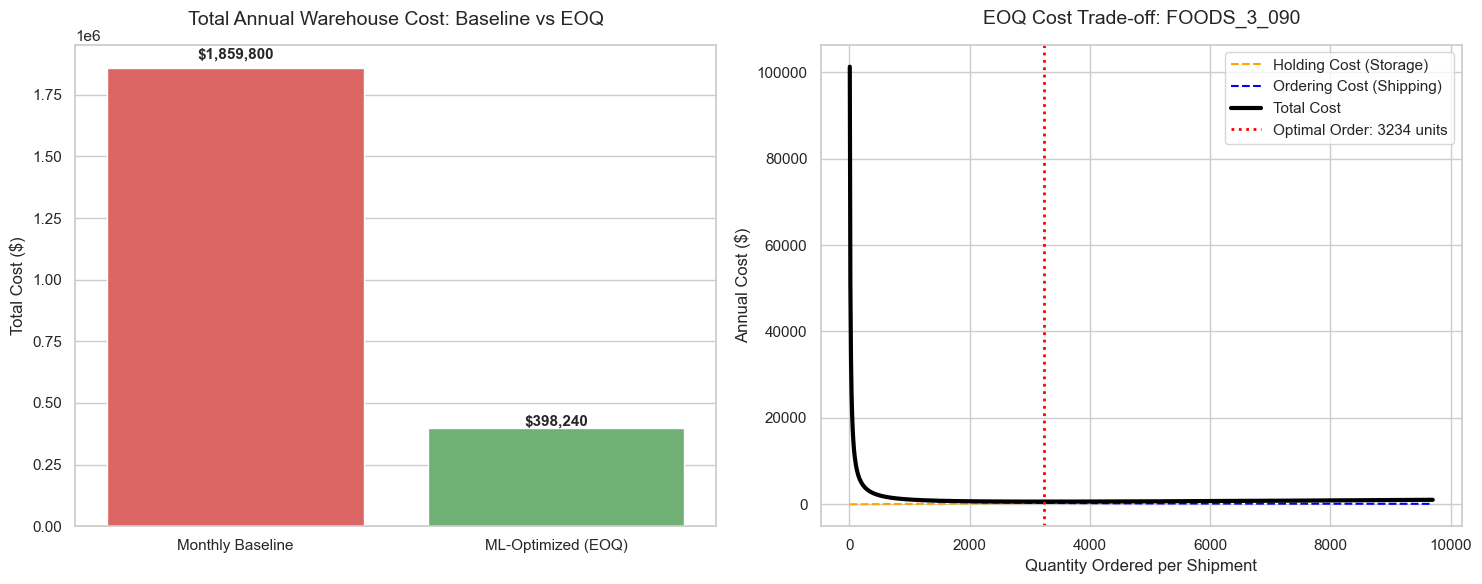

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for professional-looking charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# ==========================================
# GRAPH 1: The Total Cost Comparison Bar Chart
# ==========================================
plt.subplot(1, 2, 1)

# Get total costs across the whole warehouse
costs = [daily_inventory['tac_baseline'].sum(), daily_inventory['tac_eoq'].sum()]
labels = ['Monthly Baseline', 'ML-Optimized (EOQ)']

# Create a barplot
ax = sns.barplot(x=labels, y=costs, palette=['#ef5350', '#66bb6a'])

# Add title and labels
plt.title('Total Annual Warehouse Cost: Baseline vs EOQ', fontsize=14, pad=15)
plt.ylabel('Total Cost ($)', fontsize=12)

# Add the exact dollar amounts on top of the bars
for i, v in enumerate(costs):
    ax.text(i, v + (v * 0.02), f'${v:,.0f}', ha='center', fontweight='bold', fontsize=11)

# ==========================================
# GRAPH 2: The EOQ Trade-off Curve (for top item)
# ==========================================
plt.subplot(1, 2, 2)

# Find the highest-selling product to use as an example
top_item = daily_inventory.loc[daily_inventory['avg_daily_demand'].idxmax()]

# Generate possible order quantities (X-axis) around the optimal EOQ
q_values = np.arange(10, int(top_item['eoq_qty'] * 3), 10)

# Calculate the curve lines
holding_costs_curve = (top_item['holding_cost'] * q_values) / 2
order_costs_curve = (ORDER_COST * top_item['annual_demand']) / q_values
total_costs_curve = holding_costs_curve + order_costs_curve

# Plot the three lines
plt.plot(q_values, holding_costs_curve, label='Holding Cost (Storage)', linestyle='--', color='orange')
plt.plot(q_values, order_costs_curve, label='Ordering Cost (Shipping)', linestyle='--', color='blue')
plt.plot(q_values, total_costs_curve, label='Total Cost', linewidth=3, color='black')

# Draw a vertical line right at the lowest point of the Total Cost curve
plt.axvline(top_item['eoq_qty'], color='red', linestyle=':', linewidth=2,
            label=f"Optimal Order: {int(top_item['eoq_qty'])} units")

# Add titles and labels
plt.title(f"EOQ Cost Trade-off: {top_item['product_name']}", fontsize=14, pad=15)
plt.xlabel('Quantity Ordered per Shipment', fontsize=12)
plt.ylabel('Annual Cost ($)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()